# Arabic Reviews Sentiment Analysis

## Data Loading

In [1]:
import pandas as pd

reviews = pd.read_csv('data/CompanyReviews.csv')

reviews.head()

,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [2]:
reviews.drop(columns=['Unnamed: 0', 'company'], inplace=True)

reviews.head()

,review_description,rating
0,رائع,1
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1


## EDA

In [3]:
reviews['rating'].unique()

array([ 1, -1,  0])

In [4]:
for i in range(10):
    print(reviews['review_description'][i], reviews['rating'][i])

رائع 1
برنامج رائع جدا يساعد على تلبيه الاحتياجات بشكل اسرع 1
التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبكة..مع انه النت عندي تمام شو الحل?? -1
لماذا لا يمكننا طلب من ماكدونالدز؟ -1
البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكون فاتحه بقاله كده اكتر من شهر -1
أصبح غالي جداً -1
جميل جدا رائع. . . 1
للأسف الواحد ينصدم بعد زيادة الاسعار و للاسف بعض المطاعم اصبحت معاملتهم رديئة -1
برنامج توترز توصيل احلى من برنامجكم فاشل -1
كتير في تحسن خدمة العملاء لطفين في بعض الاخطاء التقنية لكن بتصلحوها بسرعة وبعض التاخير سياسيتكم وتسويقكم صار افضل من كريم بالنسبة الي متفقين 1


In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  40045 non-null  object
 1   rating              40046 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.8+ KB


In [6]:
reviews['review_description'].isna().value_counts()

review_description
False    40045
True         1
Name: count, dtype: int64

In [7]:
reviews.dropna(inplace=True)

reviews['review_description'].isna().value_counts()

review_description
False    40045
Name: count, dtype: int64

In [8]:
len(reviews[reviews['rating'] == 0])

1925

In [9]:
reviews = reviews[reviews['rating'] != 0]

reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38120 entries, 0 to 40042
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  38120 non-null  object
 1   rating              38120 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 893.4+ KB


In [10]:
import numpy as np

reviews['rating'] = np.where(reviews['rating'] == -1, 0, 1)

reviews.head()

,review_description,rating
0,رائع,1
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,0
3,لماذا لا يمكننا طلب من ماكدونالدز؟,0
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,0


## Data Splitting

In [11]:
target = 'rating'

X = reviews['review_description']
y = reviews[target]

X.shape, y.shape

((38120,), (38120,))

In [12]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((24396,), (6100,), (7624,))

## Training

### Model from Scratch

In [13]:
import tensorflow as tf

text_vec_layer = tf.keras.layers.TextVectorization(1000)
text_vec_layer.adapt(X_train)

In [14]:
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(1000, 5),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer='nadam',
    metrics=['accuracy'],
)

In [16]:
history = model.fit(
    X_train.values, y_train.values,
    validation_data=(X_val.values, y_val.values),
    epochs=10,
)

Epoch 1/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.6888 - loss: 0.6092 - val_accuracy: 0.7669 - val_loss: 0.5108
Epoch 2/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6586 - loss: 0.5692 - val_accuracy: 0.6275 - val_loss: 0.6015
Epoch 3/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7063 - loss: 0.5401 - val_accuracy: 0.7492 - val_loss: 0.5130
Epoch 4/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7601 - loss: 0.5106 - val_accuracy: 0.7559 - val_loss: 0.5110
Epoch 5/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.7511 - loss: 0.5299 - val_accuracy: 0.7452 - val_loss: 0.5743
Epoch 6/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7673 - loss: 0.5154 - val_accuracy: 0.7936 - val_loss: 0.4503
Epoch 7/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.8329 - loss: 0.4094 - val_accuracy: 0.8408 - val_loss: 0.3907
Epoch 8/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.8508 - loss: 0.3684 - 

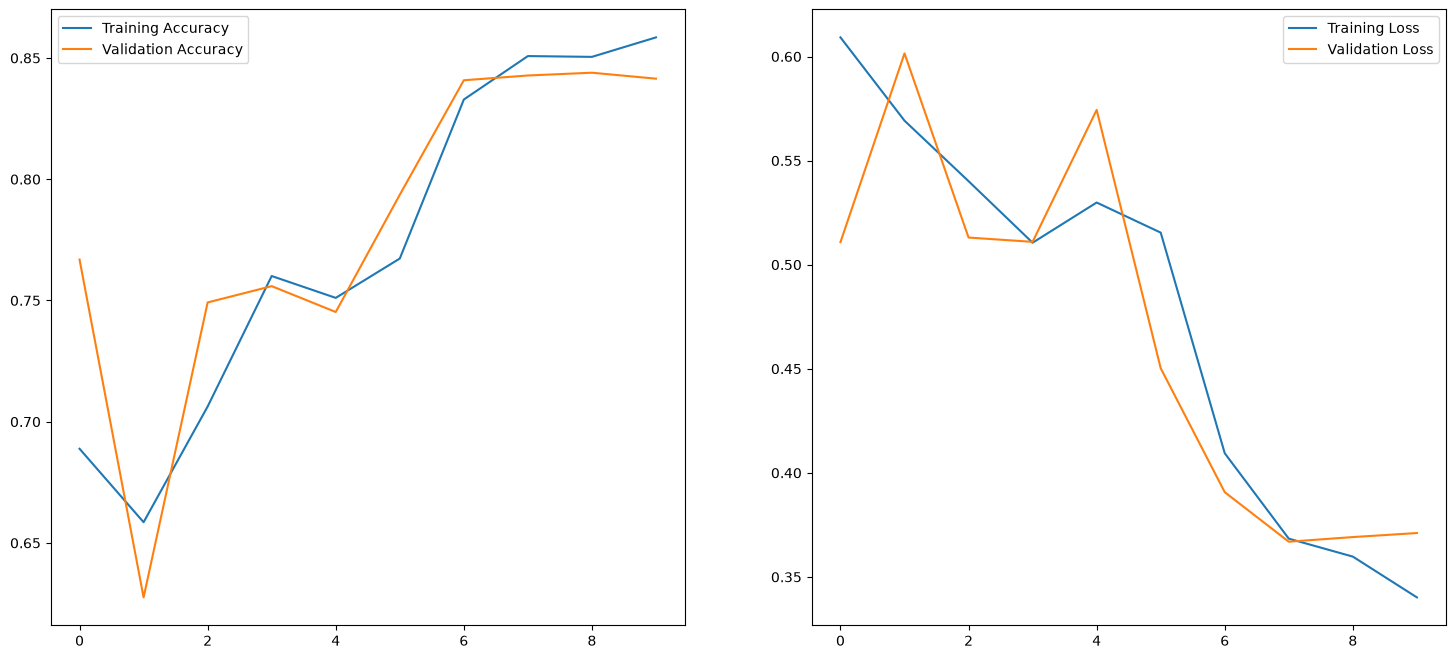

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18,8))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].legend()

plt.show()

In [18]:
y_proba = model.predict(X_test.values)

239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step


In [19]:
y_pred = np.where(y_proba > 0.5, 1, 0)
y_pred

array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [0]], shape=(7624, 1))

In [20]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8492917103882477

In [21]:
for i in range(10):
    print(f'label: {y_test.iloc[i]}, prediction: {y_pred[i]}, review: {X_test.iloc[i]}')

label: 1, prediction: [1], review: Jbfhiighhjjjjjjnnnnnnnnnnnmmmmmmmmmmmmmmmmmmmmmm
label: 1, prediction: [1], review: برنامج حلو و يستاهل
label: 0, prediction: [0], review: ما انصحكم تنزلون التطبيق الانه ماعندهم مصداقيه في اخذ الطلبات وغير عن هذا مايردون عليك لو كان عندك مشكله ومصور الشاشه كيف خدمتهم اذا كان عندك مشكله يخلونك تنتظر على فاضي واتحدهم اذا كان كلامي غلط ما يستاهلون ولا نجمه حتى صفر وايد عليهم
label: 0, prediction: [0], review: افشل شركه
label: 0, prediction: [0], review: فاشل 🤬🤬
label: 0, prediction: [0], review: نغسي يوصل طلب بموعده 😡😡 دائما اقل تاخير ساعه ،جربنا برمضان وافطرنا بعد الاذان بساعه ونص وقلنا عذره ازمه جربنا عالعيد قلنا ازمه ، هلاء برضوا طلب اتاخر ساعه ونص ومافي ازمه ،،للاسف اهمال كبير
label: 1, prediction: [1], review: سهل جدا .... مرتب ويسهل عليكم البحث عن المطاعم ... ميزة التقيم تساعد في اختيار المطاعم
label: 0, prediction: [0], review: خدمة سيئة و عروض وهمية طلبت بأستخدام كود خصم و انتظرت اكثر من ساعتين و بعدها كلمت خدمة العملاء قاللي الطلب اتلغي لان استخ

## Fine-Tuning

In [22]:
import keras_tuner as kt

def build_model(hp):
    embedding_output = hp.Int('embedding_output', min_value=2, max_value=8, default=5)
    n_neurons = hp.Int('n_neurons', min_value=64, max_value=256, default=128)

    model = tf.keras.Sequential([
        text_vec_layer,
        tf.keras.layers.Embedding(1000, embedding_output),
        tf.keras.layers.LSTM(n_neurons),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='nadam',
        metrics=['accuracy']
    )

    return model

In [23]:
random_search_tuner = kt.RandomSearch(
    build_model, objective='val_accuracy', max_trials=5, overwrite=True, seed=42
)

random_search_tuner.search(X_train.values, y_train.values, epochs=5, validation_data=(X_val.values, y_val.values))

Trial 5 Complete [00h 02m 33s]
val_accuracy: 0.8237704634666443

Best val_accuracy So Far: 0.8281967043876648
Total elapsed time: 00h 12m 47s


In [24]:
best_model = random_search_tuner.get_best_models()[0]

best_model.summary()

c:\Users\Seif Adin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 15 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 8)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 131)            │        73,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,492 (318.33 KB)

 Trainable params: 81,492 (318.33 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = best_model.fit(X_train_full.values, y_train_full.values, epochs=10)

Epoch 1/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 53s 53ms/step - accuracy: 0.8068 - loss: 0.4811
Epoch 2/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.8255 - loss: 0.4599
Epoch 3/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.8271 - loss: 0.4483
Epoch 4/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 51s 53ms/step - accuracy: 0.8391 - loss: 0.4013
Epoch 5/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.8513 - loss: 0.3808
Epoch 6/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.8562 - loss: 0.3636
Epoch 7/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.8604 - loss: 0.3396
Epoch 8/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.8637 - loss: 0.3306
Epoch 9/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.8653 - loss: 0.3245
Epoch 10/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.8666 - loss: 0.3179


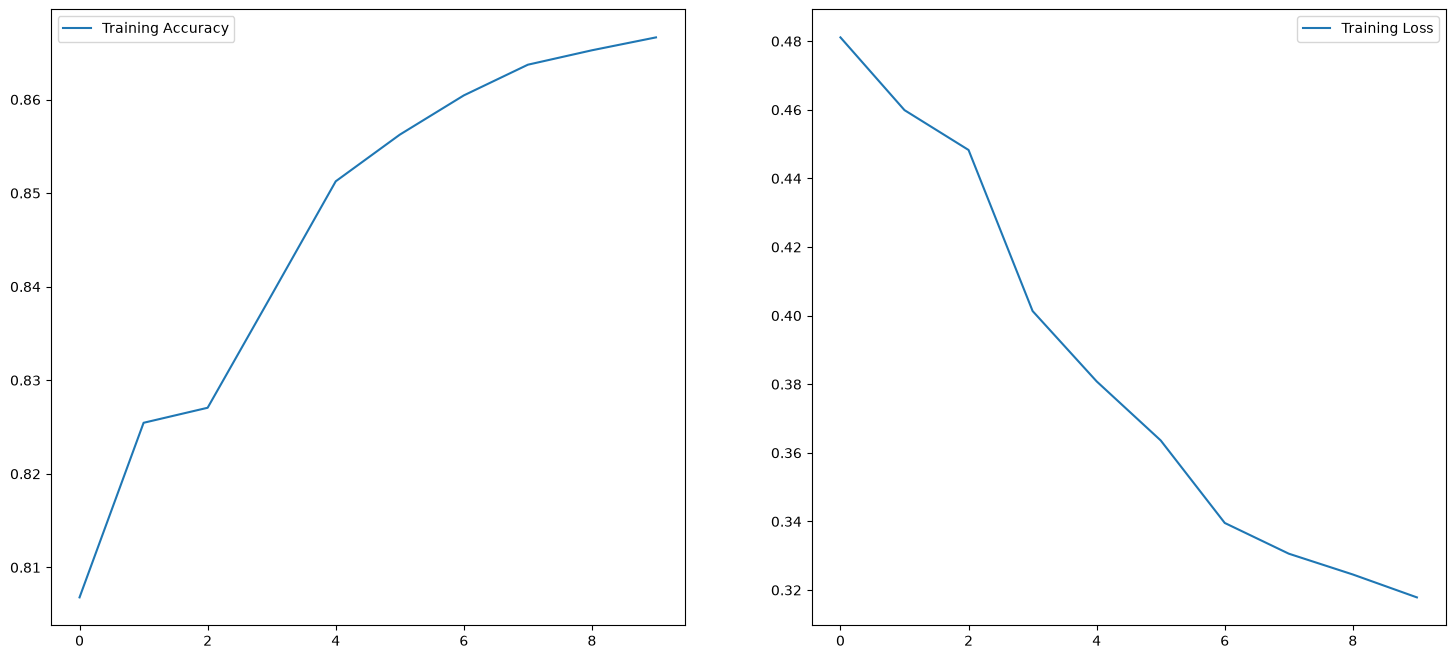

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18,8))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].legend()

plt.show()

In [27]:
y_proba = best_model.predict(X_test.values)

y_pred = np.where(y_proba > 0.5, 1, 0)
y_pred

239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step


array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [0]], shape=(7624, 1))

In [28]:
accuracy_score(y_test, y_pred)

0.8601783840503673

In [29]:
for i in range(10):
    print(f'label: {y_test.iloc[i]}, prediction: {y_pred[i]}, review: {X_test.iloc[i]}')

label: 1, prediction: [1], review: Jbfhiighhjjjjjjnnnnnnnnnnnmmmmmmmmmmmmmmmmmmmmmm
label: 1, prediction: [1], review: برنامج حلو و يستاهل
label: 0, prediction: [0], review: ما انصحكم تنزلون التطبيق الانه ماعندهم مصداقيه في اخذ الطلبات وغير عن هذا مايردون عليك لو كان عندك مشكله ومصور الشاشه كيف خدمتهم اذا كان عندك مشكله يخلونك تنتظر على فاضي واتحدهم اذا كان كلامي غلط ما يستاهلون ولا نجمه حتى صفر وايد عليهم
label: 0, prediction: [0], review: افشل شركه
label: 0, prediction: [0], review: فاشل 🤬🤬
label: 0, prediction: [0], review: نغسي يوصل طلب بموعده 😡😡 دائما اقل تاخير ساعه ،جربنا برمضان وافطرنا بعد الاذان بساعه ونص وقلنا عذره ازمه جربنا عالعيد قلنا ازمه ، هلاء برضوا طلب اتاخر ساعه ونص ومافي ازمه ،،للاسف اهمال كبير
label: 1, prediction: [1], review: سهل جدا .... مرتب ويسهل عليكم البحث عن المطاعم ... ميزة التقيم تساعد في اختيار المطاعم
label: 0, prediction: [0], review: خدمة سيئة و عروض وهمية طلبت بأستخدام كود خصم و انتظرت اكثر من ساعتين و بعدها كلمت خدمة العملاء قاللي الطلب اتلغي لان استخ